# Confronto Pratico: Watershed vs. K-Means
**UFPI - Campus Senador Helvidio Nunes de Barros**  
**Disciplina:** Topicos Especiais em Visao Computacional - Prof. Jose Denes Lima Araujo  
**Grupo 4:** Segmentacao Baseada em Regiao (Secao 10.5 - Gonzalez & Woods)  
**Parte Pratica:** Integrante 3 (Analise Comparativa Bidirecional)

---

### Proposta Experimental
Avaliar empiricamente as duas tecnicas da Secao 10.5 em dois cenarios opostos do mundo real:
1. **Cenario 1 (Moedas Tangentes):** Geometria regular, toque fisico e cores homogeneas.
2. **Cenario 2 (Cena Natural da Borboleta):** Cores ricas, variacoes tonais, texturas e bordas complexas.


In [1]:
# Instalacao das dependencias para execucao no Google Colab
!pip install -q opencv-python numpy matplotlib scikit-image scipy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Importacao das bibliotecas necessarias
import os
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.segmentation import watershed as skimage_watershed

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

os.makedirs('imagens', exist_ok=True)
os.makedirs('resultados', exist_ok=True)

# Verificacao das imagens de teste
path_moedas = os.path.join('imagens', 'moedas_sobrepostas.jpg')
if not os.path.exists(path_moedas):
    url_m = 'https://raw.githubusercontent.com/opencv/opencv/4.x/doc/py_tutorials/py_imgproc/py_watershed/images/water_coins.jpg'
    urllib.request.urlretrieve(url_m, path_moedas)

path_borboleta = os.path.join('imagens', 'cena_colorida.jpg')
if not os.path.exists(path_borboleta):
    url_b = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg'
    urllib.request.urlretrieve(url_b, path_borboleta)

print('Imagens de teste prontas.')


Imagens de teste prontas.


## PARTE 1: Cenario 1 - Moedas Sobrepostas (Slide 11)
Neste cenario, temos 24 moedas de bronze que se tocam sobre fundo claro.
- **K-Means (K=2):** Agrupa apenas pela cor do pixel. Como todas as moedas tem a mesma cor de bronze, o K-Means une todas no mesmo cluster.
- **Watershed com Marcadores:** Utiliza a Transformada de Distancia Euclidiana para modelar os centros como picos topograficos e constroi barragens morfológicas de 1 pixel nos pontos de contato.


In [3]:
# Leitura das moedas
img_m_bgr = cv2.imread(path_moedas)
img_m_rgb = cv2.cvtColor(img_m_bgr, cv2.COLOR_BGR2RGB)
gray_m = cv2.cvtColor(img_m_bgr, cv2.COLOR_BGR2GRAY)

# 1. K-Means (K=2)
amostras_m = img_m_rgb.reshape((-1, 3)).astype(np.float32)
criterio = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels_k2, centers_k2 = cv2.kmeans(amostras_m, 2, None, criterio, 10, cv2.KMEANS_RANDOM_CENTERS)
seg_k2 = np.uint8(centers_k2)[labels_k2.flatten()].reshape(img_m_rgb.shape)
mapa_k2 = labels_k2.reshape((img_m_rgb.shape[0], img_m_rgb.shape[1]))

cluster_moeda = np.argmin(np.mean(centers_k2, axis=1))
mascara_k2 = np.uint8(mapa_k2 == cluster_moeda)
num_comp_k2, _ = cv2.connectedComponents(mascara_k2)
qtd_k2 = num_comp_k2 - 1

# 2. Watershed com Marcadores
_, thresh_m = cv2.threshold(gray_m, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = np.ones((3, 3), np.uint8)
opening_m = cv2.morphologyEx(thresh_m, cv2.MORPH_OPEN, kernel, iterations=2)
sure_bg_m = cv2.dilate(opening_m, kernel, iterations=3)

dist_m = cv2.distanceTransform(opening_m, cv2.DIST_L2, 5)
_, sure_fg_m = cv2.threshold(dist_m, 0.7 * dist_m.max(), 255, 0)
sure_fg_m = np.uint8(sure_fg_m)

unknown_m = cv2.subtract(sure_bg_m, sure_fg_m)
_, markers_m = cv2.connectedComponents(sure_fg_m)
markers_m = markers_m + 1
markers_m[unknown_m == 255] = 0

img_ws_m = img_m_rgb.copy()
res_ws_m = cv2.watershed(img_ws_m, markers_m)
img_ws_m[res_ws_m == -1] = [255, 0, 0]
qtd_ws_m = len(np.unique(res_ws_m)) - 2

print(f'Cenario 1 (Moedas):')
print(f'-> K-Means (K=2): detectou {qtd_k2} bloco continuo (falha na separacao de toque).')
print(f'-> Watershed: individualizou {qtd_ws_m} moedas com sucesso.')


Cenario 1 (Moedas):
-> K-Means (K=2): detectou 2 bloco continuo (falha na separacao de toque).
-> Watershed: individualizou 24 moedas com sucesso.


Grafico do Cenario 1 salvo em: resultados\comparativo_toque_moedas.png


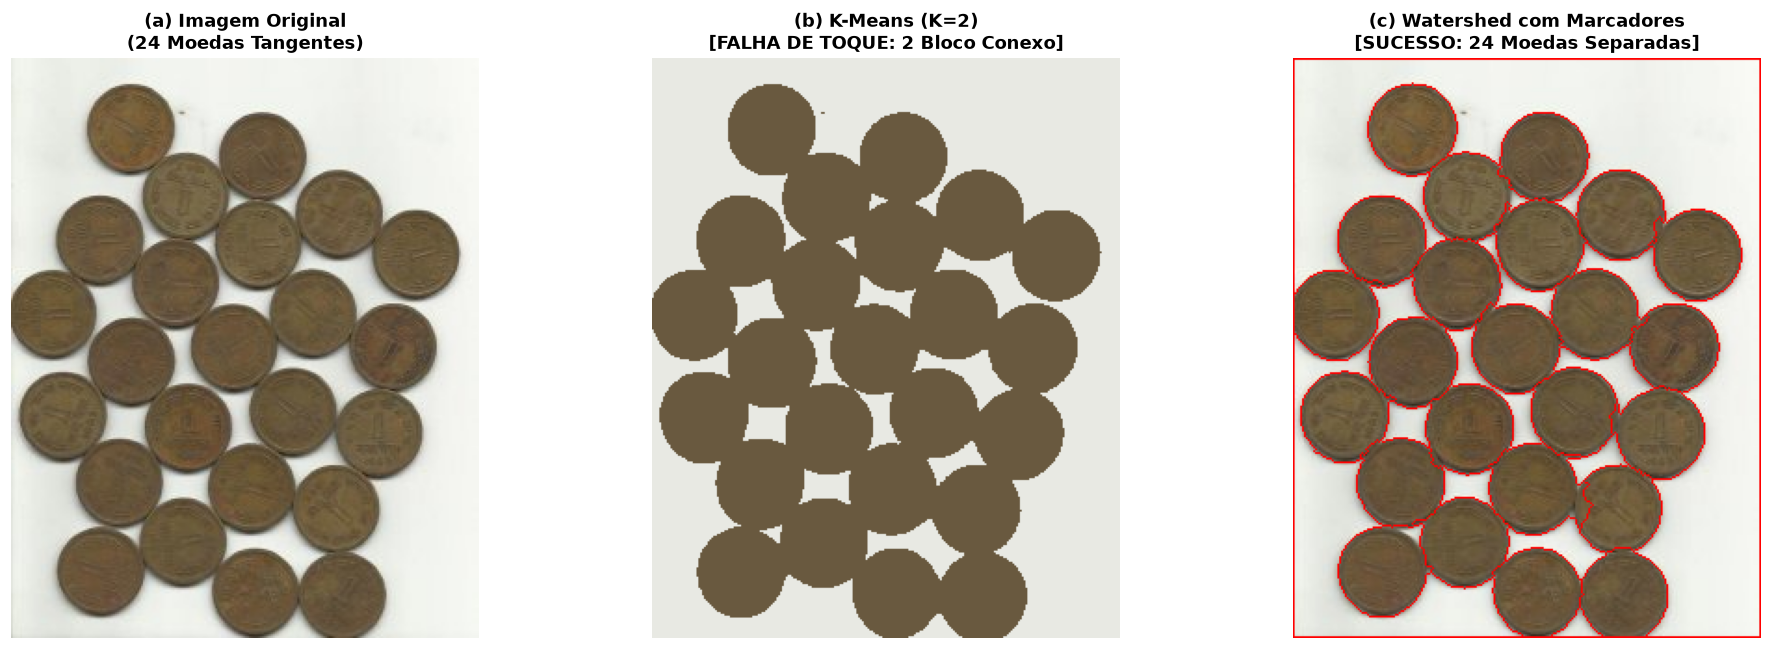

In [4]:
# Visualizacao Comparativa - Cenario 1 (Moedas)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_m_rgb)
axes[0].set_title('(a) Imagem Original\n(24 Moedas Tangentes)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(seg_k2)
axes[1].set_title(f'(b) K-Means (K=2)\n[FALHA DE TOQUE: {qtd_k2} Bloco Conexo]', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(img_ws_m)
axes[2].set_title(f'(c) Watershed com Marcadores\n[SUCESSO: {qtd_ws_m} Moedas Separadas]', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
out_moedas = os.path.join('resultados', 'comparativo_toque_moedas.png')
plt.savefig(out_moedas, dpi=180, bbox_inches='tight')
plt.savefig(os.path.join('resultados', 'comparativo_toque_watershed_vs_kmeans.png'), dpi=180, bbox_inches='tight')
print('Grafico do Cenario 1 salvo em:', out_moedas)
plt.show()


## PARTE 2: Cenario 2 - Cena Natural da Borboleta (Slide 12)
Aqui a situacao se inverte radicalmente:
- A imagem possui 3 planos visuais (objeto, vegetacao e fundo) com cores ricas, iluminacao variavel e nervuras complexas.
- **K-Means (K=3 em L\*a\*b\*):** Funciona com excelente precisao semantica, agrupando os tres planos de cor e atenuando sombras atraves do desacoplamento da luminancia.
- **Watershed sem Marcadores Pre-Definidos:** Se aplicarmos o Watershed diretamente sobre o gradiente da imagem (como ilustrado na Figura 10.57 do Gonzalez & Woods), cada textura, nervura de folha e escama da asa vira um minimo regional espurio. O resultado e uma **sobre-segmentacao severa (milhares de fragmentos)**.


In [5]:
# Leitura da borboleta
img_b_bgr = cv2.imread(path_borboleta)
img_b_rgb = cv2.cvtColor(img_b_bgr, cv2.COLOR_BGR2RGB)
gray_b = cv2.cvtColor(img_b_bgr, cv2.COLOR_BGR2GRAY)

# 1. K-Means (K=3) no espaco CIE L*a*b*
img_b_lab = cv2.cvtColor(img_b_bgr, cv2.COLOR_BGR2LAB)
amostras_b = img_b_lab.reshape((-1, 3)).astype(np.float32)
_, labels_b, centers_b = cv2.kmeans(amostras_b, 3, None, criterio, 10, cv2.KMEANS_RANDOM_CENTERS)
centers_b = np.uint8(centers_b)
seg_b_lab = centers_b[labels_b.flatten()].reshape(img_b_lab.shape)
seg_b_rgb = cv2.cvtColor(seg_b_lab, cv2.COLOR_LAB2RGB)

# 2. Watershed sobre o Gradiente da Imagem (Demonstracao da Sobre-Segmentacao)
# Calculo do modulo do gradiente de Sobel
sobelx = cv2.Sobel(gray_b, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray_b, cv2.CV_64F, 0, 1, ksize=3)
grad_b = np.hypot(sobelx, sobely)

# Minimos locais do gradiente (visto na Secao 10.5 do livro)
minimos_locais = ndimage.minimum_filter(grad_b, size=5) == grad_b
marcadores_grad, num_minimos = ndimage.label(minimos_locais)

# Execucao do Watershed sobre o gradiente
ws_grad = skimage_watershed(grad_b, marcadores_grad)
linhas_ws = (ndimage.sobel(ws_grad, axis=0) != 0) | (ndimage.sobel(ws_grad, axis=1) != 0)

img_ws_b = img_b_rgb.copy()
img_ws_b[linhas_ws] = [255, 0, 0]  # Linhas de sobre-segmentacao em vermelho

print(f'Cenario 2 (Cena da Borboleta):')
print(f'-> K-Means (K=3 em L*a*b*): isolou perfeitamente os 3 planos semanticos.')
print(f'-> Watershed direto no gradiente: gerou {num_minimos} micro-bacias (sobre-segmentacao severa).')


Cenario 2 (Cena da Borboleta):
-> K-Means (K=3 em L*a*b*): isolou perfeitamente os 3 planos semanticos.
-> Watershed direto no gradiente: gerou 5759 micro-bacias (sobre-segmentacao severa).


Grafico do Cenario 2 salvo em: resultados\comparativo_cena_borboleta.png


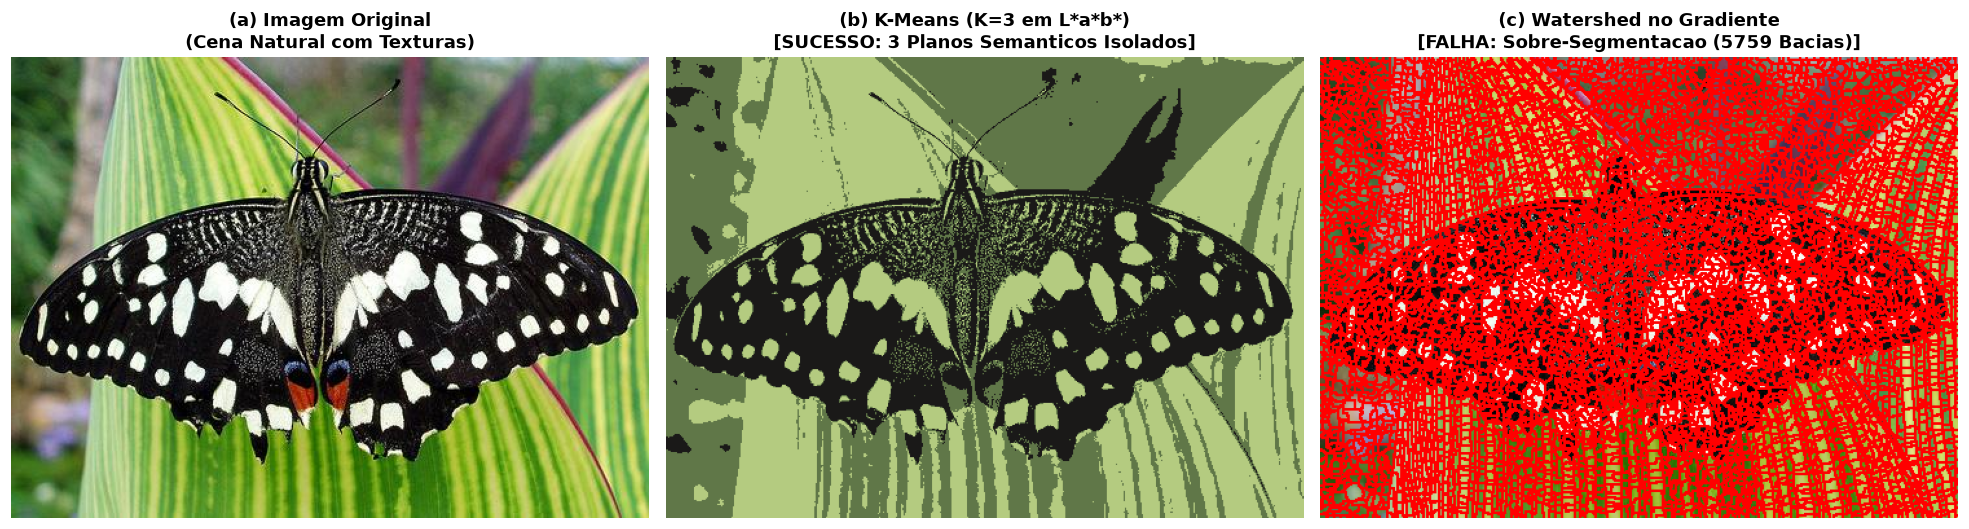

In [6]:
# Visualizacao Comparativa - Cenario 2 (Borboleta)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_b_rgb)
axes[0].set_title('(a) Imagem Original\n(Cena Natural com Texturas)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(seg_b_rgb)
axes[1].set_title('(b) K-Means (K=3 em L*a*b*)\n[SUCESSO: 3 Planos Semanticos Isolados]', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(img_ws_b)
axes[2].set_title(f'(c) Watershed no Gradiente\n[FALHA: Sobre-Segmentacao ({num_minimos} Bacias)]', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
out_borboleta = os.path.join('resultados', 'comparativo_cena_borboleta.png')
plt.savefig(out_borboleta, dpi=180, bbox_inches='tight')
print('Grafico do Cenario 2 salvo em:', out_borboleta)
plt.show()


## PARTE 3: Sintese Comparativa e Recomendacoes de Engenharia (Slide 13)

### Matriz Comparativa Definitiva

| Criterio Tecnico | Transformada de Watershed | Clustering K-Means | Conclusao Pratica |
| :--- | :--- | :--- | :--- |
| **Separacao de Toque** | Excelente. A Transformada de Distancia cria relevo que constroi barragens no estrangulamento. | Ineficaz. Objetos encostados da mesma cor tem a mesma assinatura espectral e caem no mesmo cluster. | Vencedor: **Watershed** (Cenario 1) |
| **Cenas Naturais e Texturas** | Dificil. Sem marcadores manuais, o gradiente gera milhares de micro-bacias (sobre-segmentacao). | Excelente. O espaco L\*a\*b\* isola planos de cores sem depender de contornos ou gradientes continuos. | Vencedor: **K-Means** (Cenario 2) |
| **Dependencia de Bordas** | Elevada. Depende de gradientes continuos ou formato geometrico regular para calcular distancias. | Independente. Segmenta cores mesmo que o contorno do objeto seja difuso, borrado ou inexistente. | Vencedor: **K-Means** |
| **Prontidao para Metrologia** | Imediata. Entrega regioes conexas fechadas com rotulos individuais para contagem e calculo de area. | Requer Pos-processamento. Entrega nuvens dispersas de pixels sem restricao espacial de vizinhanca. | Vencedor: **Watershed** |

---

### Diretrizes de Engenharia: Quando Utilizar Cada Metodo?
- **Use Watershed com Marcadores:** Para inspecao industrial, contagem automatizada e metrologia (ex: moedas em esteira, celulas em microscopia, graos, pastilhas farmaceuticas).
- **Use K-Means e Superpixels (SLIC):** Para simplificacao de cenas complexas, remocao de fundo, quantizacao de paleta de cores e pre-processamento semantico para redes neurais convolucionais (CNNs).
